## Predict 24 hourly prices for 10 February 2026

In [1]:
import pandas as pd

import optuna

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("../data/processed/features_dataset.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

In [3]:
train = df[df["timestamp"] < "2026-01-01"].copy()
test = df[df["timestamp"] >= "2026-01-01"].copy()

In [15]:
target = "price"

safe_feature_cols = [
    "dayofweek",
    "month",

    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",

    "actual_residual_load_lag_24",
    "actual_residual_load_lag_48",
    "actual_residual_load_lag_168",

    "actual_wind_total_lag_24",
    "actual_wind_total_lag_48",
    "actual_wind_total_lag_168",

    "actual_fossil_total_lag_24",
    "actual_fossil_total_lag_48",
    "actual_fossil_total_lag_168"
]

X = df[safe_feature_cols]
y = df[target]

print("Number of safe features:", len(safe_feature_cols))

Number of safe features: 15


In [16]:
best_params = {
    "n_estimators": 393,
    "learning_rate": 0.059,
    "max_depth": 6,
    "subsample": 0.744,
    "colsample_bytree": 0.873,
    "reg_alpha": 0.67,
    "reg_lambda": 3.48
}

final_model = XGBRegressor(
    **best_params,
    random_state=42
)

final_model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.873
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [17]:
future_timestamps = pd.date_range(
    start="2026-02-10 00:00:00",
    end="2026-02-10 23:00:00",
    freq="h"
)

future_df = pd.DataFrame({"timestamp": future_timestamps})

In [18]:
df_future = pd.concat([df, future_df], ignore_index=True)

df_future = df_future.sort_values("timestamp").reset_index(drop=True)
df_future = df_future.set_index("timestamp")

In [32]:
print(safe_feature_cols)

['dayofweek', 'month', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'actual_residual_load_lag_24', 'actual_residual_load_lag_48', 'actual_residual_load_lag_168', 'actual_wind_total_lag_24', 'actual_wind_total_lag_48', 'actual_wind_total_lag_168', 'actual_fossil_total_lag_24', 'actual_fossil_total_lag_48', 'actual_fossil_total_lag_168']


In [21]:
df_future["hour"] = df_future.index.hour
df_future["dayofweek"] = df_future.index.dayofweek
df_future["month"] = df_future.index.month

df_future["lag_24"] = df_future["price"].shift(24)
df_future["lag_48"] = df_future["price"].shift(48)
df_future["lag_168"] = df_future["price"].shift(168)

df_future["rolling_mean_24"] = df_future["price"].shift(24).rolling(24).mean()

In [22]:
external_cols = [
    "actual_residual_load",
    "actual_wind_total",
    "actual_solar",
    "actual_renewable_total",
    "actual_fossil_total"
]

for col in external_cols:
    df_future[f"{col}_lag_24"] = df_future[col].shift(24)
    df_future[f"{col}_lag_48"] = df_future[col].shift(48)
    df_future[f"{col}_lag_168"] = df_future[col].shift(168)

In [23]:
future_features = df_future.loc[future_timestamps].copy()

In [24]:
X_future = future_features[safe_feature_cols]

In [25]:
X_future.isna().sum().sort_values(ascending=False)

dayofweek                       0
month                           0
lag_24                          0
lag_48                          0
lag_168                         0
rolling_mean_24                 0
actual_residual_load_lag_24     0
actual_residual_load_lag_48     0
actual_residual_load_lag_168    0
actual_wind_total_lag_24        0
actual_wind_total_lag_48        0
actual_wind_total_lag_168       0
actual_fossil_total_lag_24      0
actual_fossil_total_lag_48      0
actual_fossil_total_lag_168     0
dtype: int64

In [26]:
future_predictions = final_model.predict(X_future)

future_results = pd.DataFrame({
    "timestamp": future_timestamps,
    "predicted_price": future_predictions
})

future_results

,timestamp,predicted_price
0,2026-02-10 00:00:00,105.046249
1,2026-02-10 01:00:00,105.060127
2,2026-02-10 02:00:00,102.672203
3,2026-02-10 03:00:00,102.325844
4,2026-02-10 04:00:00,102.692039
5,2026-02-10 05:00:00,106.600906
6,2026-02-10 06:00:00,128.041031
7,2026-02-10 07:00:00,145.500565
8,2026-02-10 08:00:00,174.885300
9,2026-02-10 09:00:00,159.203293


In [27]:
future_results.to_csv(
    "../outputs/predictions/final_prediction_10_feb_2026.csv",
    index=False
)

Compare predictions vs actual 10 Feb data

In [28]:

actual_df = pd.read_csv("../data/raw/day_ahead_prices_2026_02_10.csv", sep=";")

actual_df = actual_df[[
    "Start date",
    "Germany/Luxembourg [€/MWh] Calculated resolutions"
]].copy()

actual_df.rename(columns={
    "Start date": "timestamp",
    "Germany/Luxembourg [€/MWh] Calculated resolutions": "actual_price"
}, inplace=True)

actual_df["timestamp"] = pd.to_datetime(actual_df["timestamp"])

# Convert numeric (same logic as before)
actual_df["actual_price"] = (
    actual_df["actual_price"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

actual_df["actual_price"] = pd.to_numeric(actual_df["actual_price"], errors="coerce")

actual_df.head()

C:\Users\ankit\AppData\Local\Temp\ipykernel_8684\947490357.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  actual_df["timestamp"] = pd.to_datetime(actual_df["timestamp"])


,timestamp,actual_price
0,2026-02-10 00:00:00,104.64
1,2026-02-10 01:00:00,103.75
2,2026-02-10 02:00:00,102.75
3,2026-02-10 03:00:00,102.44
4,2026-02-10 04:00:00,102.44


In [29]:
comparison = future_results.merge(
    actual_df,
    on="timestamp",
    how="inner"
)

comparison

,timestamp,predicted_price,actual_price
0,2026-02-10 00:00:00,105.046249,104.64
1,2026-02-10 01:00:00,105.060127,103.75
2,2026-02-10 02:00:00,102.672203,102.75
3,2026-02-10 03:00:00,102.325844,102.44
4,2026-02-10 04:00:00,102.692039,102.44
5,2026-02-10 05:00:00,106.600906,105.43
6,2026-02-10 06:00:00,128.041031,119.92
7,2026-02-10 07:00:00,145.500565,134.89
8,2026-02-10 08:00:00,174.885300,143.83
9,2026-02-10 09:00:00,159.203293,132.08


In [30]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    comparison["actual_price"],
    comparison["predicted_price"]
)

print(f"Final Prediction MAE (10 Feb 2026): {mae:.3f}")

Final Prediction MAE (10 Feb 2026): 22.665


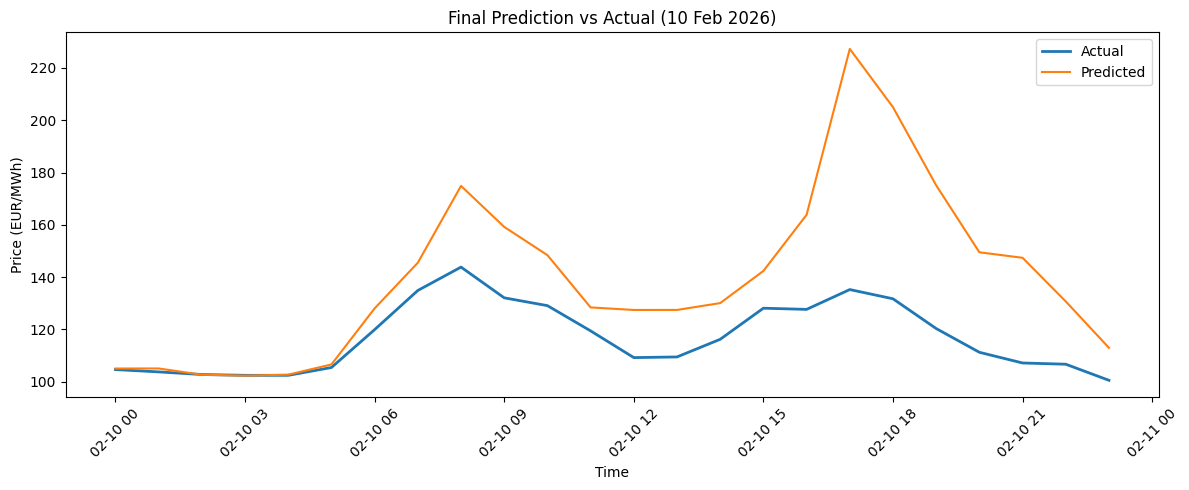

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(comparison["timestamp"], comparison["actual_price"], label="Actual", linewidth=2)
plt.plot(comparison["timestamp"], comparison["predicted_price"], label="Predicted")

plt.title("Final Prediction vs Actual (10 Feb 2026)")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/figures/xgboost_vs_actual.png", dpi=300)

plt.show()

In [77]:
comparison.to_csv(
    "../outputs/predictions/final_vs_actual_10_feb_2026.csv",
    index=False
)

The model achieves a test MAE of ~9.6 on historical data. However, when applied to true future forecasting (10 February 2026), the MAE increases to ~22.7.

This gap highlights the difference between evaluation on historical test data and real-world forecasting conditions, where only past information is available. The model still captures general price trends but struggles with sudden price spikes and volatility.

### To compare xgboost, ridge and prophet final prediction.

In [33]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X, y)

ridge_pred = ridge_model.predict(X_future)

ridge_results = pd.DataFrame({
    "timestamp": future_timestamps,
    "ridge_prediction": ridge_pred
})

In [34]:
ridge_comparison = ridge_results.merge(
    actual_df,
    on="timestamp"
)

from sklearn.metrics import mean_absolute_error

ridge_mae = mean_absolute_error(
    ridge_comparison["actual_price"],
    ridge_comparison["ridge_prediction"]
)

print(f"Ridge Final MAE: {ridge_mae:.3f}")

Ridge Final MAE: 22.140


In [35]:
from prophet import Prophet

prophet_df = df.rename(columns={"timestamp": "ds", "price": "y"})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=24, freq="h")

forecast = model.predict(future)

Importing plotly failed. Interactive plots will not work.
09:28:23 - cmdstanpy - INFO - Chain [1] start processing
09:28:56 - cmdstanpy - INFO - Chain [1] done processing


In [81]:
prophet_pred = forecast.set_index("ds").loc[future_timestamps]["yhat"].values

prophet_results = pd.DataFrame({
    "timestamp": future_timestamps,
    "prophet_prediction": prophet_pred
})

In [82]:
prophet_comparison = prophet_results.merge(
    actual_df,
    on="timestamp"
)

prophet_mae = mean_absolute_error(
    prophet_comparison["actual_price"],
    prophet_comparison["prophet_prediction"]
)

print(f"Prophet Final MAE: {prophet_mae:.3f}")

Prophet Final MAE: 16.607


In [83]:
print("Final Prediction MAE Comparison")
print("--------------------------------")
print(f"XGBoost: {mae:.3f}")
print(f"Ridge:   {ridge_mae:.3f}")
print(f"Prophet: {prophet_mae:.3f}")

Final Prediction MAE Comparison
--------------------------------
XGBoost: 22.665
Ridge:   22.140
Prophet: 16.607


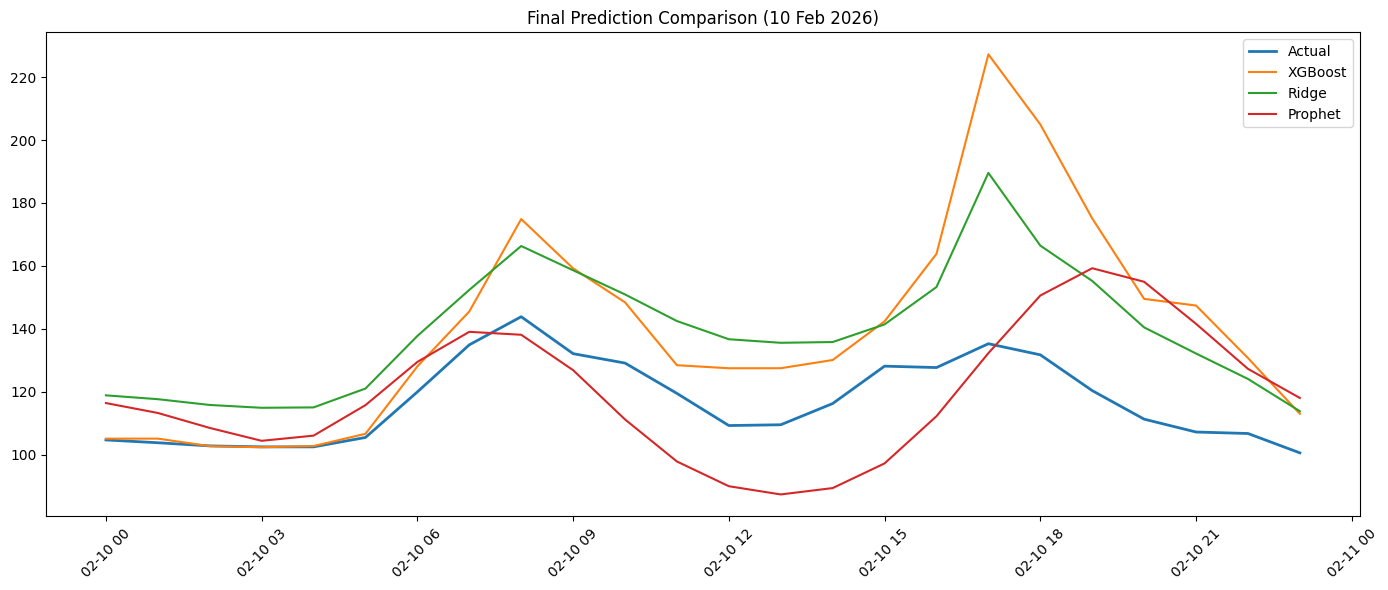

In [89]:
comparison_all = comparison.copy()

comparison_all = comparison_all.merge(
    ridge_results,
    on="timestamp"
)

comparison_all = comparison_all.merge(
    prophet_results,
    on="timestamp"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(comparison_all["timestamp"], comparison_all["actual_price"], label="Actual", linewidth=2)
plt.plot(comparison_all["timestamp"], comparison_all["predicted_price"], label="XGBoost")
plt.plot(comparison_all["timestamp"], comparison_all["ridge_prediction"], label="Ridge")
plt.plot(comparison_all["timestamp"], comparison_all["prophet_prediction"], label="Prophet")

plt.legend()
plt.title("Final Prediction Comparison (10 Feb 2026)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/figures/final_prediction_comparison.png", dpi=300)

plt.show()

Although XGBoost achieved the best performance on the historical test set (MAE ≈ 9.6), its advantage diminished in the real forecasting scenario (10 February 2026).

When only past information is available, Prophet outperformed both Ridge and XGBoost (MAE ≈ 16.6), as it is specifically designed to capture time-series seasonality and trends.

This highlights the importance of distinguishing between:
1. model evaluation on historical data
2. real-world forecasting conditions

Machine learning models benefit strongly from external features, but when such features are unavailable for future prediction, classical time-series models like Prophet can perform better.